In [40]:
import mitgcm_assim.cost as cost

# Read all costfunction* files in current directory
ds_sep = cost.read_costfunction('/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_ad/')
ds_nov = cost.read_costfunction('/data/SO3/edavenport/tpose6/nov2012/run_ad_withGLD/')
ds_jan = cost.read_costfunction('/data/SO3/edavenport/tpose6/jan2013/run_ad/')
ds_mar = cost.read_costfunction('/data/SO3/edavenport/tpose6/mar2013/run_ad/')

In [41]:
ds_sep = ds_sep.isel(iter=-1)
ds_nov = ds_nov.isel(iter=-1)
ds_jan = ds_jan.isel(iter=-1)
ds_mar = ds_mar.isel(iter=-1)

# Identify the coordinate values that start with 'xx'
to_drop = [val for val in ds_mar.dataset.values if str(val).startswith('xx')]

# Drop those specific coordinates
ds_mar = ds_mar.drop_sel(dataset=to_drop)
ds_sep = ds_sep.drop_sel(dataset=to_drop)
ds_nov = ds_nov.drop_sel(dataset=to_drop)
ds_jan = ds_jan.drop_sel(dataset=to_drop)

# 1. Create a mask: True for anything that does NOT contain "GLD"
mask = ~ds_mar.dataset.str.contains("GLD")
# 2. Apply the mask to the dataset
ds_mar = ds_mar.sel(dataset=mask)
mask = ~ds_sep.dataset.str.contains("GLD")
ds_sep = ds_sep.sel(dataset=mask)
mask = ~ds_nov.dataset.str.contains("GLD")
ds_nov = ds_nov.sel(dataset=mask)
mask = ~ds_jan.dataset.str.contains("GLD")
ds_jan = ds_jan.sel(dataset=mask)

In [42]:
ds_mar = ds_mar.drop_sel(dataset='fc')
ds_sep = ds_sep.drop_sel(dataset='fc')
ds_nov = ds_nov.drop_sel(dataset='fc')
ds_jan = ds_jan.drop_sel(dataset='fc')

In [43]:
import re

# 1. Define a function to strip the year (e.g., _2013_)
def remove_year(name):
    # This looks for an underscore, 4 digits, and another underscore
    return re.sub(r'_\d{4}_', '_', str(name))

# 3. Assign the cleaned names back and group duplicates
# We use .groupby('dataset').sum() in case stripping the year 
# results in multiple entries with the same name.
new_coords = [remove_year(val) for val in ds_mar.dataset.values]
ds_mar = ds_mar.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_year(val) for val in ds_sep.dataset.values]
ds_sep = ds_sep.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_year(val) for val in ds_nov.dataset.values]
ds_nov = ds_nov.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_year(val) for val in ds_jan.dataset.values]
ds_jan = ds_jan.assign_coords(dataset=new_coords).groupby('dataset').sum()

def remove_v2(name):
    return re.sub(r'_v2_', '_', str(name))

# 3. Assign the cleaned names back and group duplicates
# We use .groupby('dataset').sum() in case stripping the year 
# results in multiple entries with the same name.
new_coords = [remove_v2(val) for val in ds_mar.dataset.values]
ds_mar = ds_mar.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_v2(val) for val in ds_sep.dataset.values]
ds_sep = ds_sep.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_v2(val) for val in ds_nov.dataset.values]
ds_nov = ds_nov.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_v2(val) for val in ds_jan.dataset.values]
ds_jan = ds_jan.assign_coords(dataset=new_coords).groupby('dataset').sum()

def remove_ED(name):
    return re.sub(r'_ED_', '_', str(name))

# 3. Assign the cleaned names back and group duplicates
# We use .groupby('dataset').sum() in case stripping the year 
# results in multiple entries with the same name.
new_coords = [remove_ED(val) for val in ds_mar.dataset.values]
ds_mar = ds_mar.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_ED(val) for val in ds_sep.dataset.values]
ds_sep = ds_sep.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_ED(val) for val in ds_nov.dataset.values]
ds_nov = ds_nov.assign_coords(dataset=new_coords).groupby('dataset').sum()
new_coords = [remove_ED(val) for val in ds_jan.dataset.values]
ds_jan = ds_jan.assign_coords(dataset=new_coords).groupby('dataset').sum()

In [44]:
ds_mar.dataset

<xarray.DataArray 'dataset' (dataset: 16)> Size: 1kB
array(['HDO_TP_CTD_w_prof_S', 'HDO_TP_CTD_w_prof_T', 'SIO_TP_XBT_w_prof_T',
       'TAO_WO_ADCP_prof_U', 'TAO_WO_ADCP_prof_V', 'TAO_WO_CTD_daily_prof_S',
       'TAO_WO_CTD_daily_prof_T', 'TAO_WO_CUR_prof_U', 'TAO_WO_CUR_prof_V',
       'USGO_TP_PFL_D_w_prof_S', 'USGO_TP_PFL_D_w_prof_T',
       'WOD_TP_XBT_w_prof_T', 'sshv4-gfo', 'sshv4-mdt', 'sshv4-tp', 'sst-MW'],
      dtype='<U23')
Coordinates:
  * dataset  (dataset) <U23 1kB 'HDO_TP_CTD_w_prof_S' ... 'sst-MW'
    iter     int64 8B 16

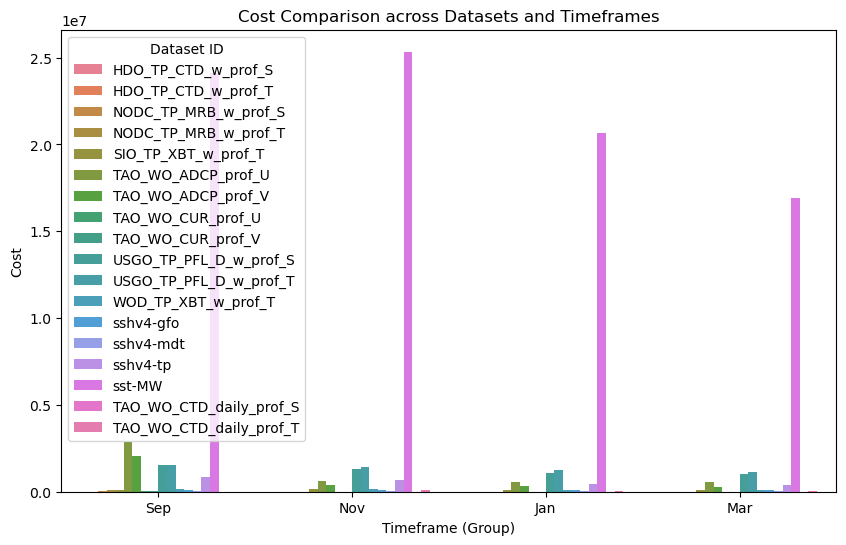

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a dictionary of the datasets
datasets = {
    'Sep': ds_sep,
    'Nov': ds_nov,
    'Jan': ds_jan,
    'Mar': ds_mar
}


df_list = []

for label, ds in datasets.items():
    # 2. Select the last iteration if the 'iter' dimension still exists
    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=-1)
    else:
        ds_subset = ds
    
    # 3. Convert only the 'cost' variable to a DataFrame
    # This automatically uses the 'dataset' coordinate as an index
    df = ds_subset[['cost']].to_dataframe().reset_index()
    
    # 4. Add a column to identify which group (month) this data belongs to
    df['Group'] = label
    
    df_list.append(df)

# 5. Combine all dataframes into one
df_total = pd.concat(df_list, ignore_index=True)

# 6. Plot using Seaborn
fig = plt.figure(figsize=(10, 6))
sns.barplot(data=df_total, x='Group', y='cost', hue='dataset')

plt.title('Cost Comparison across Datasets and Timeframes')
plt.xlabel('Timeframe (Group)')
plt.ylabel('Cost')
plt.legend(title='Dataset ID')
plt.show()
fig.savefig('cost.png')

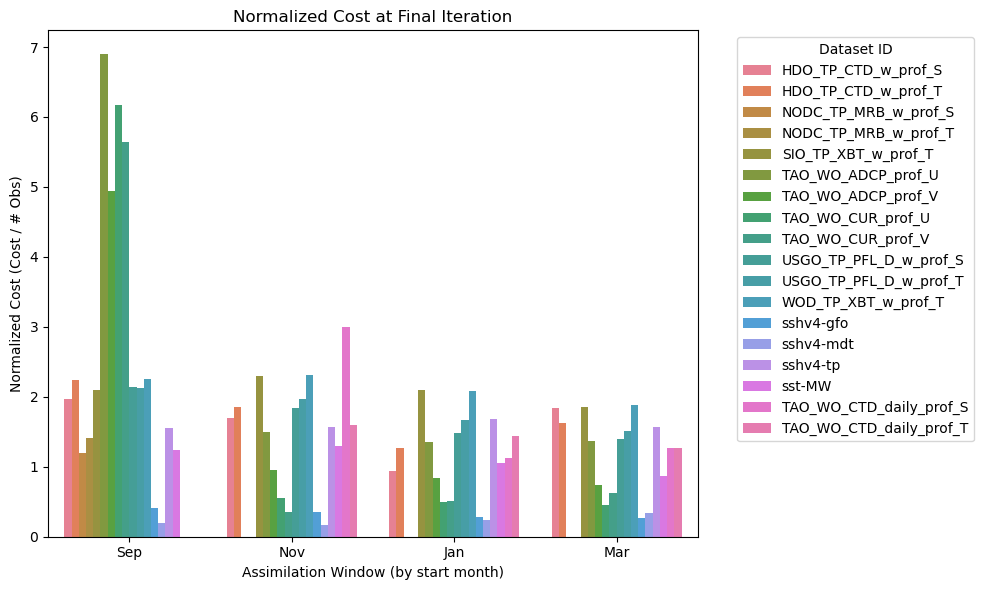

In [49]:
datasets = {
    'Sep': ds_sep,
    'Nov': ds_nov,
    'Jan': ds_jan,
    'Mar': ds_mar
}

df_list = []

for label, ds in datasets.items():
    # 1. Select the last iteration
    if 'iter' in ds.dims:
        ds_subset = ds.isel(iter=-1)
    else:
        ds_subset = ds
    
    # 2. Calculate normalized cost 
    ds_subset['norm_cost'] = ds_subset['cost'] / ds_subset['n_obs']
    
    # 3. Convert to DataFrame (include the new variable)
    df = ds_subset[['norm_cost']].to_dataframe().reset_index()
    df['Group'] = label
    
    df_list.append(df)

# 4. Combine
df_total = pd.concat(df_list, ignore_index=True)

# 5. Plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(data=df_total, x='Group', y='norm_cost', hue='dataset')

plt.title('Normalized Cost at Final Iteration')
plt.xlabel('Assimilation Window (by start month)')
plt.ylabel('Normalized Cost (Cost / # Obs)')
plt.legend(title='Dataset ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

fig.savefig('normalized_cost.png')